# 04 — Model Evaluation
**VitalTracker | LSTM Autoencoder**

Outputs: threshold, precision/recall/F1, ROC AUC, confusion matrix, model card.

In [1]:
import os
BASE_PATH      = r'C:\Users\Saqib\OneDrive\Desktop\VitalTracker'
PROCESSED_PATH = os.path.join(BASE_PATH, 'data', 'processed')
MODEL_PATH     = os.path.join(BASE_PATH, 'models', 'lstm_autoencoder')
for f in ['X_test.npy', 'train_errors.npy', 'test_errors.npy', 'test_meta.csv']:
    print(f'{f}: {"✓" if os.path.exists(os.path.join(PROCESSED_PATH, f)) else "✗ MISSING"}')
print(f'model.keras: {"✓" if os.path.exists(os.path.join(MODEL_PATH, "model.keras")) else "✗ MISSING"}')

X_test.npy: ✓
train_errors.npy: ✓
test_errors.npy: ✓
test_meta.csv: ✓
model.keras: ✓


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, pickle, warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, auc
)
tf.config.set_visible_devices([], 'GPU')

model = tf.keras.models.load_model(os.path.join(MODEL_PATH, 'model.keras'))
with open(os.path.join(MODEL_PATH, 'config.json')) as f:
    config = json.load(f)
with open(os.path.join(MODEL_PATH, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)

WINDOW_SIZE = config['input_shape'][0]
BATCH_SIZE  = 64
P95 = config['train_error_stats']['p95']
P99 = config['train_error_stats']['p99']
print(f'Model loaded | p95={P95:.6f} | p99={P99:.6f}')

Model loaded | p95=0.002774 | p99=0.006123


In [3]:
X_test       = np.load(os.path.join(PROCESSED_PATH, 'X_test.npy'))
train_errors = np.load(os.path.join(PROCESSED_PATH, 'train_errors.npy'))
test_errors  = np.load(os.path.join(PROCESSED_PATH, 'test_errors.npy'))
test_meta    = pd.read_csv(os.path.join(PROCESSED_PATH, 'test_meta.csv'))
print(f'X_test: {X_test.shape} | test_errors: {test_errors.shape}')

X_test: (4118, 60, 2) | test_errors: (4118,)


### 1. False Positive Rate on Normal Data

p95 (0.002774) → FP rate on normal data: 5.00%
p99 (0.006123) → FP rate on normal data: 1.00%


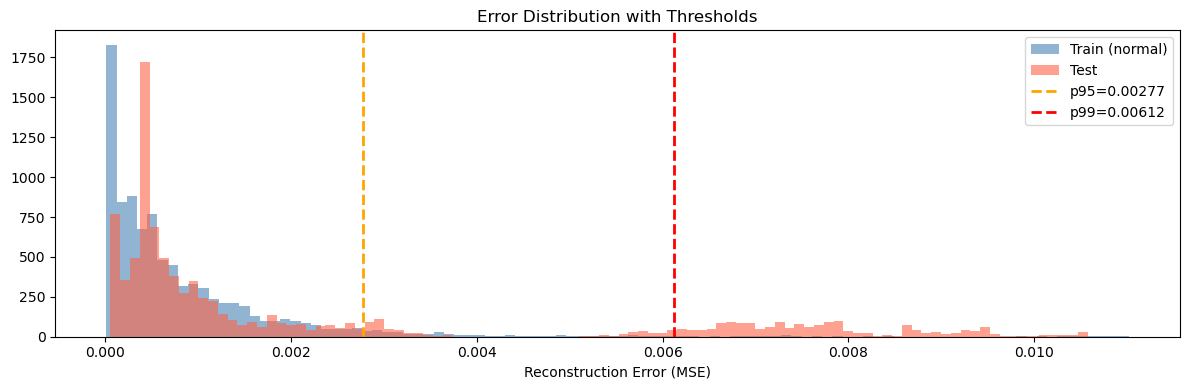

In [4]:
for label, thresh in [('p95', P95), ('p99', P99)]:
    fpr = (train_errors > thresh).mean() * 100
    print(f'{label} ({thresh:.6f}) → FP rate on normal data: {fpr:.2f}%')

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(train_errors, bins=100, alpha=0.6, color='steelblue', label='Train (normal)', density=True)
ax.hist(test_errors,  bins=100, alpha=0.6, color='tomato',    label='Test',           density=True)
ax.axvline(P95, color='orange', linestyle='--', linewidth=2, label=f'p95={P95:.5f}')
ax.axvline(P99, color='red',    linestyle='--', linewidth=2, label=f'p99={P99:.5f}')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_title('Error Distribution with Thresholds')
ax.legend()
plt.tight_layout()
plt.show()

### 2. Inject Synthetic Anomalies

In [5]:
hr_min,   hr_max   = scaler.data_min_[0], scaler.data_max_[0]
spo2_min, spo2_max = scaler.data_min_[1], scaler.data_max_[1]
def norm_hr(v):   return (v - hr_min)   / (hr_max   - hr_min)
def norm_spo2(v): return (v - spo2_min) / (spo2_max - spo2_min)

np.random.seed(42)
N_ANOMALIES   = 500
base_idxs     = np.random.choice(len(X_test), N_ANOMALIES, replace=False)
anom_windows  = X_test[base_idxs].copy()
anom_types    = np.random.choice(['bradycardia', 'hypoxia', 'combined'], N_ANOMALIES)

for i, atype in enumerate(anom_types):
    if atype == 'bradycardia':
        anom_windows[i, 30:, 0] = norm_hr(np.random.uniform(35, 45))   + np.random.normal(0, 0.01, 30)
    elif atype == 'hypoxia':
        anom_windows[i, 30:, 1] = norm_spo2(np.random.uniform(80, 88)) + np.random.normal(0, 0.01, 30)
    elif atype == 'combined':
        anom_windows[i, 30:, 0] = norm_hr(np.random.uniform(35, 50))   + np.random.normal(0, 0.01, 30)
        anom_windows[i, 30:, 1] = norm_spo2(np.random.uniform(80, 88)) + np.random.normal(0, 0.01, 30)
anom_windows = np.clip(anom_windows, 0, 1)

print('Injected anomalies:')
for t in ['bradycardia', 'hypoxia', 'combined']:
    print(f'  {t}: {(anom_types == t).sum()}')

Injected anomalies:
  bradycardia: 174
  hypoxia: 155
  combined: 171


### 3. Anomaly Scores + Metrics

In [6]:
anom_pred   = model.predict(anom_windows, batch_size=BATCH_SIZE, verbose=1)
anom_errors = np.mean(np.square(anom_windows - anom_pred), axis=(1, 2))

all_errors = np.concatenate([test_errors, anom_errors])
all_labels = np.concatenate([np.zeros(len(test_errors)), np.ones(len(anom_errors))])

print('Metrics at each threshold:\n')
rows = []
for label, thresh in [('p95', P95), ('p99', P99)]:
    preds = (all_errors > thresh).astype(int)
    rows.append({
        'Threshold' : label,
        'Value'     : round(thresh, 6),
        'Precision' : round(precision_score(all_labels, preds, zero_division=0), 4),
        'Recall'    : round(recall_score(all_labels, preds), 4),
        'F1'        : round(f1_score(all_labels, preds), 4),
        'FP Rate'   : round((test_errors > thresh).mean(), 4)
    })
print(pd.DataFrame(rows).to_string(index=False))

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 364ms/step
Metrics at each threshold:

Threshold    Value  Precision  Recall     F1  FP Rate
      p95 0.002774     0.3338     1.0 0.5005   0.2424
      p99 0.006123     0.3949     1.0 0.5663   0.1860


### 4. Confusion Matrix + ROC/PR Curves

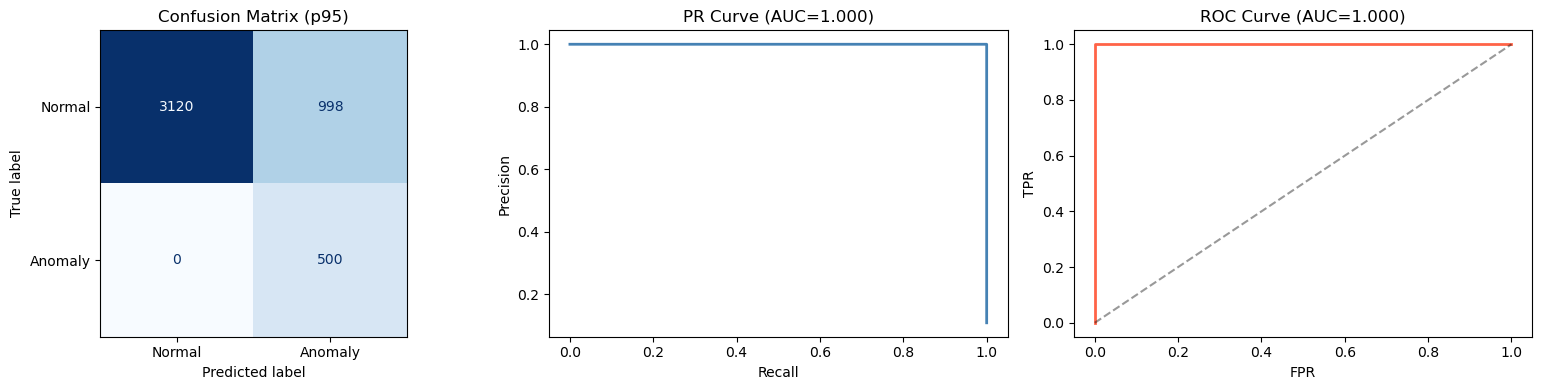

ROC AUC: 1.0000 | PR AUC: 1.0000


In [7]:
# Confusion matrix
preds_p95 = (all_errors > P95).astype(int)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ConfusionMatrixDisplay(confusion_matrix(all_labels, preds_p95),
                       display_labels=['Normal','Anomaly']
                      ).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix (p95)')

# PR curve
prec, rec, _ = precision_recall_curve(all_labels, all_errors)
pr_auc = auc(rec, prec)
axes[1].plot(rec, prec, color='steelblue', linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'PR Curve (AUC={pr_auc:.3f})')

# ROC curve
fpr_v, tpr_v, _ = roc_curve(all_labels, all_errors)
roc_auc = auc(fpr_v, tpr_v)
axes[2].plot(fpr_v, tpr_v, color='tomato', linewidth=2)
axes[2].plot([0,1],[0,1],'k--',alpha=0.4)
axes[2].set_xlabel('FPR')
axes[2].set_ylabel('TPR')
axes[2].set_title(f'ROC Curve (AUC={roc_auc:.3f})')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, 'evaluation_plots.png'), dpi=150)
plt.show()
print(f'ROC AUC: {roc_auc:.4f} | PR AUC: {pr_auc:.4f}')

### 5. Anomaly Score Timeline (Single Patient)

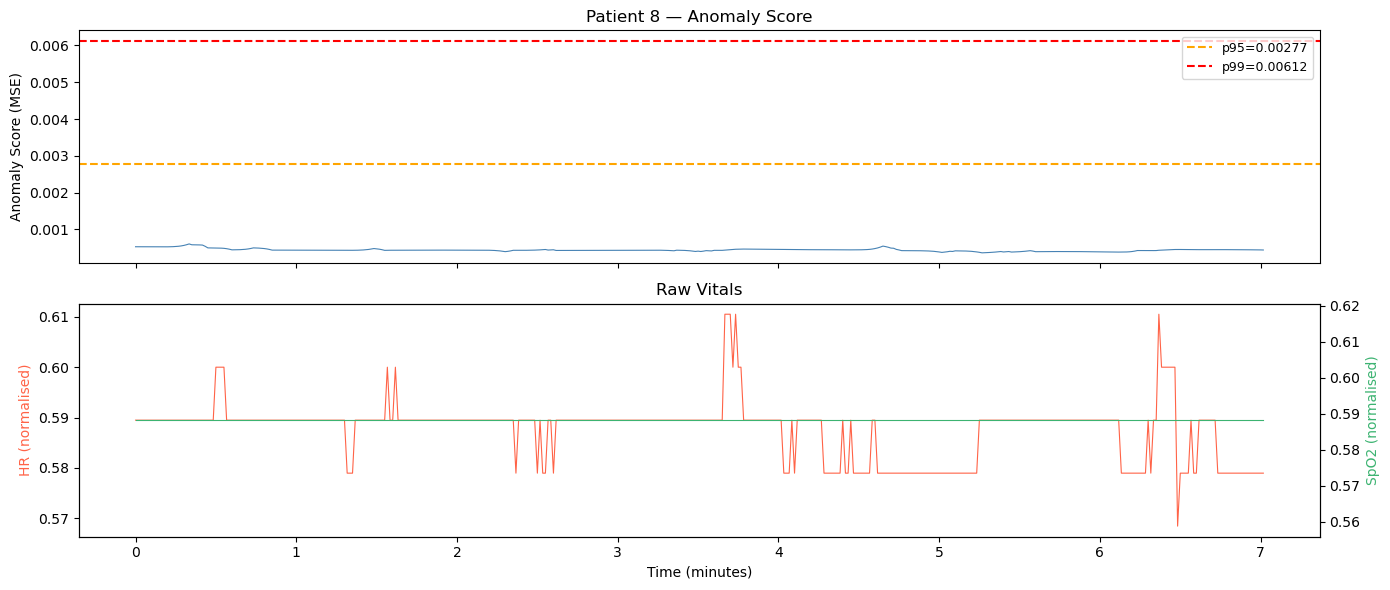

In [8]:
pid          = test_meta['patient_id'].iloc[0]
mask         = test_meta['patient_id'] == pid
p_errors     = test_errors[mask]
p_times      = test_meta[mask]['start_time'].values / 60
p_windows    = X_test[mask]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(p_times, p_errors, color='steelblue', linewidth=0.8)
axes[0].axhline(P95, color='orange', linestyle='--', label=f'p95={P95:.5f}')
axes[0].axhline(P99, color='red',    linestyle='--', label=f'p99={P99:.5f}')
axes[0].fill_between(p_times, p_errors, P95,
                     where=(p_errors > P95), color='orange', alpha=0.3)
axes[0].set_ylabel('Anomaly Score (MSE)')
axes[0].set_title(f'Patient {pid} — Anomaly Score')
axes[0].legend(fontsize=9)

axes[1].plot(p_times, p_windows[:, -1, 0], color='tomato',        linewidth=0.8, label='HR')
ax2 = axes[1].twinx()
ax2.plot(p_times,    p_windows[:, -1, 1], color='mediumseagreen', linewidth=0.8, label='SpO2')
axes[1].set_xlabel('Time (minutes)')
axes[1].set_ylabel('HR (normalised)',   color='tomato')
ax2.set_ylabel(     'SpO2 (normalised)', color='mediumseagreen')
axes[1].set_title('Raw Vitals')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, 'anomaly_timeline.png'), dpi=150)
plt.show()

### 6. Per-Anomaly-Type Detection Rate

Detection rate per anomaly type (p95 threshold):

  bradycardia    : 100.0% detected  (mean error: 0.042503)
  hypoxia        : 100.0% detected  (mean error: 0.091862)
  combined       : 100.0% detected  (mean error: 0.115032)


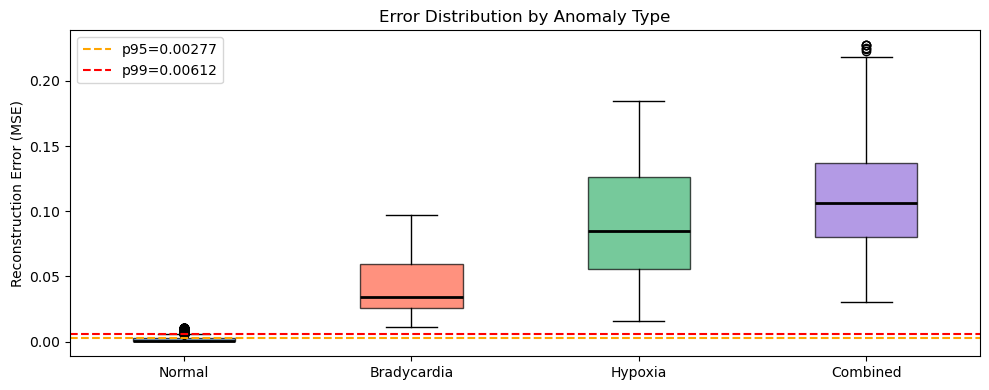

In [9]:
print('Detection rate per anomaly type (p95 threshold):\n')
for atype in ['bradycardia', 'hypoxia', 'combined']:
    m = anom_types == atype
    rate = (anom_errors[m] > P95).mean() * 100
    print(f'  {atype:<15}: {rate:.1f}% detected  (mean error: {anom_errors[m].mean():.6f})')

fig, ax = plt.subplots(figsize=(10, 4))
bp = ax.boxplot(
    [test_errors,
     anom_errors[anom_types=='bradycardia'],
     anom_errors[anom_types=='hypoxia'],
     anom_errors[anom_types=='combined']],
    labels=['Normal','Bradycardia','Hypoxia','Combined'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp['boxes'], ['steelblue','tomato','mediumseagreen','mediumpurple']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.axhline(P95, color='orange', linestyle='--', label=f'p95={P95:.5f}')
ax.axhline(P99, color='red',    linestyle='--', label=f'p99={P99:.5f}')
ax.set_ylabel('Reconstruction Error (MSE)')
ax.set_title('Error Distribution by Anomaly Type')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, 'error_by_type.png'), dpi=150)
plt.show()

### 7. Save Final Threshold + Model Card

In [11]:
FINAL_THRESHOLD = P95
preds_final     = (all_errors > FINAL_THRESHOLD).astype(int)
final_metrics   = {
    'precision'          : round(precision_score(all_labels, preds_final, zero_division=0), 4),
    'recall'             : round(recall_score(all_labels, preds_final), 4),
    'f1'                 : round(f1_score(all_labels, preds_final), 4),
    'false_positive_rate': round(float((test_errors > FINAL_THRESHOLD).mean()), 4),
    'roc_auc'            : round(roc_auc, 4),
    'pr_auc'             : round(pr_auc, 4),
}

config['anomaly_threshold'] = FINAL_THRESHOLD
config['evaluation'] = {
    'threshold_strategy': 'p95 of training reconstruction error',
    **final_metrics,
    'n_test_windows'    : int(len(test_errors)),
    'n_anomaly_windows' : N_ANOMALIES,
    'anomaly_types'     : ['bradycardia', 'hypoxia', 'combined'],
}
with open(os.path.join(MODEL_PATH, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print('=' * 50)
print('  MODEL CARD — VitalTracker')
print('=' * 50)
print(f'  Architecture     : LSTM Autoencoder')
print(f'  Input            : 60s windows, HR + SpO2')
print(f'  Training data    : PhysioNet BIDMC (53 patients)')
print(f'  Threshold        : {FINAL_THRESHOLD:.6f} (p95)')
print()
for k, v in final_metrics.items():
    print(f'  {k:<22}: {v}')


  MODEL CARD — VitalTracker
  Architecture     : LSTM Autoencoder
  Input            : 60s windows, HR + SpO2
  Training data    : PhysioNet BIDMC (53 patients)
  Threshold        : 0.002774 (p95)

  precision             : 0.3338
  recall                : 1.0
  f1                    : 0.5005
  false_positive_rate   : 0.2424
  roc_auc               : 1.0
  pr_auc                : 1.0
